# One-to-One Skew-GRAM : résolution du problème du plus long chemin par embeddings de nœuds appris via Skip-Gram

**Projet universitaire — Optimisation, Deep Learning & NLP appliqués aux graphes**

**Date :** 2026-07-19

---

## Résumé

Ce notebook part d'un objectif académique classique — construire un modèle de *Word Embedding* fondé sur le **Skip-Gram**, puis proposer une variante optimisée, le **One-to-One Skew-GRAM** — mais l'applique à un terrain différent de celui habituellement utilisé en NLP : des **graphes aléatoires orientés** (Erdős–Rényi), pour lesquels on dispose d'une **vérité terrain** produite par un solveur d'optimisation combinatoire (ILP).

Le principe du Skip-Gram (Mikolov et al., 2013) — apprendre des représentations vectorielles à partir de co-occurrences dans des séquences — est ici transposé aux graphes suivant le paradigme **DeepWalk / node2vec** (Perozzi et al., 2014 ; Grover & Leskovec, 2016) : un nœud joue le rôle d'un mot, une marche aléatoire (*random walk*) joue le rôle d'une phrase. Les embeddings appris sont ensuite utilisés comme **heuristique pour résoudre un vrai problème d'optimisation NP-difficile : le plus long chemin simple dans un graphe orienté**, dont on connaît par ailleurs la solution (ou la meilleure solution trouvée) via un solveur exact **ILP2 (Integer Linear Programming)** fourni avec le jeu de données.

Le **One-to-One Skew-GRAM** est notre proposition d'amélioration du Skip-Gram classique, motivée par une observation simple : *contrairement à un mot dans une phrase, un nœud ne peut apparaître qu'une seule fois dans un chemin*. Le Skip-Gram classique n'a aucune notion d'unicité ; notre variante l'intègre à la fois pendant l'entraînement (échantillonnage négatif structurel, sous-échantillonnage des nœuds de haut degré) et pendant le décodage (une distribution **skewed** — déformée/masquée — qui retire la masse de probabilité des nœuds déjà visités, garantissant une correspondance **one-to-one** valide).

## Table des matières

0. Configuration et graine aléatoire
1. Exploration du dataset
2. Prétraitement : du texte au graphe
3. Construction des couples Skip-Gram
4. Skip-Gram classique (implémentation from scratch)
5. One-to-One Skew-GRAM : conception et implémentation
6. Entraînement
7. Évaluation comparative
8. Visualisation (PCA / t-SNE)
9. Discussion
10. Conclusion


## Note méthodologique — pourquoi ce notebook ne parle pas de « texte »

Le dataset fourni pour ce projet (dossier Google Drive `erdos_renyi`) ne contient **pas de corpus textuel**. Il contient environ 890 instances de graphes aléatoires **orientés** de type Erdős–Rényi, nommées `100_<k>`, chacune avec trois fichiers :

| Fichier | Contenu |
|---|---|
| `graphD.txt` | Un graphe orienté G(100, p) : 100 nœuds, arêtes `a-b` signifiant **a → b** (vérifié empiriquement, voir §1), probabilité p (ex. `P:0.08`) |
| `graphG.txt` | Un second graphe orienté indépendant sur les mêmes 100 nœuds, plus dense |
| `solution.txt` | Le résultat d'un solveur exact **ILP2** pour le **problème du plus long chemin simple** dans `graphD` : le chemin trouvé, sa longueur, le temps d'exécution — ou `"No solution found"` si le solveur n'a pas abouti dans le temps imparti |

Toutes les étapes demandées dans l'énoncé original (nettoyage, tokenization, stopwords, vocabulaire, Skip-Gram, Negative Sampling, PCA/t-SNE, comparaison quantitative, etc.) sont conservées mais **transposées du domaine texte au domaine graphe**, selon la correspondance suivante :

| Concept NLP | Équivalent utilisé ici |
|---|---|
| Corpus / documents | Ensemble des instances de graphes disponibles |
| Phrase | Marche aléatoire (*random walk*) sur le graphe |
| Mot | Nœud (identifiant 1..100) |
| Vocabulaire | Ensemble des nœuds du graphe (taille = N) |
| Fréquence des mots | Fréquence de visite des nœuds dans les marches |
| Nettoyage, caractères spéciaux, minuscules | Sans objet (données déjà numériques) ; nœuds isolés exclus des marches |
| Stopwords | Sous-échantillonnage des nœuds de très haut degré (*hubs*) |
| Lemmatisation / Stemming | Sans objet — pas de morphologie sur des identifiants de nœuds |
| Tokenization | Génération des marches aléatoires |
| Texte → indices | Triviale : les nœuds sont déjà des entiers |
| Analogies de mots | Analogies structurelles : *u − voisin(u) + voisin(v) ≈ v* |

`nltk` et `spacy` ne sont donc pas utilisés (pas de texte à traiter) ; `gensim` est utilisé une seule fois, en §7, comme **base de comparaison** (Word2Vec entraîné sur les mêmes marches aléatoires), conformément à l'énoncé qui l'autorise « uniquement pour comparaison éventuelle ».

**Limite de reproductibilité des données :** le dossier Drive contient ~890 instances, mais leur téléchargement via l'API publique de Google Drive est soumis à un quota anti-abus par fichier/IP, atteint à plusieurs reprises pendant la collecte (voir `data/README.md` pour le détail et la procédure d'extension). Le nombre exact d'instances effectivement disponibles localement est affiché de façon dynamique ci-dessous (§1) et **n'est pas codé en dur** : tout le code de ce notebook s'adapte automatiquement au contenu de `data/raw/` — relancer le téléchargement puis ré-exécuter le notebook permet d'obtenir des statistiques plus robustes sans changer une ligne de code.


## 0. Configuration et graine aléatoire <a id="0"></a>

On importe les librairies utilisées (`numpy`, `pandas`, `matplotlib`, `scikit-learn`, `torch`, `gensim`, `networkx`) et on fixe une **graine aléatoire unique (`SEED = 42`)** pour tous les générateurs (`random`, `numpy`, `torch`) afin de garantir la reproductibilité intégrale des résultats (marches aléatoires, initialisation des embeddings, tirage des négatifs, PCA/t-SNE).

Les hyperparamètres globaux du pipeline (taille des marches, dimension des embeddings, fenêtre de contexte, etc.) sont centralisés ici pour faciliter les expériences.

In [1]:
import os
import re
import math
import time
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --- Reproductibilité : une graine unique pour tous les générateurs ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Chemins ---
DATA_DIR = "data/raw"
FIGURES_DIR = "figures"
RESULTS_DIR = "results"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# --- Hyperparamètres globaux ---
NUM_WALKS = 40          # nombre de marches aléatoires par nœud de départ
WALK_LENGTH = 30         # longueur maximale d'une marche
WINDOW = 3                # taille de la fenêtre de contexte Skip-Gram
EMBED_DIM = 32            # dimension des embeddings
EPOCHS = 8                # époques d'entraînement
K_NEG = 5                  # nombre d'échantillons négatifs par paire positive
BATCH_SIZE = 128
LR = 0.01                  # taux d'apprentissage (Adam)
BEAM_WIDTH = 4             # largeur du beam search au décodage (Skew-GRAM)
DECODE_TAU = 0.5           # température de la softmax de décodage

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

print("Setup OK — SEED =", SEED)

Setup OK — SEED = 42


## 1. Exploration du dataset <a id="1"></a>

### 1.1 Chargement des graphes et des solutions ILP2

Chaque instance est composée de trois fichiers texte. Le format de `graphD.txt` / `graphG.txt` est :

```
N:100
P:0.08
1-9
1-30
...
```

où `N` est le nombre de nœuds, `P` la probabilité d'arête du modèle Erdős–Rényi, et chaque ligne `a-b` un **arc orienté a → b**. Cette orientation a été vérifiée empiriquement : les chemins solutions d'ILP2 suivent systématiquement l'ordre littéral `a→b` des lignes du fichier, jamais l'inverse — un graphe non orienté aurait autorisé des chemins beaucoup plus longs que ceux réellement trouvés par ILP2 (vérifié par une recherche aléatoire naïve, très inférieure aux longueurs ILP2 en non-orienté, très cohérente en orienté).

`solution.txt` contient soit un chemin trouvé par le solveur exact ILP2 :
```
Result of ILP2 for 100_121:
Path length: 6
Path : [13, 92, 41, starts...]
Execution time: 19.5942 seconds
```
soit un échec :
```
Result of ILP2 for 100_1:
No solution found.
Execution time: 0.4958 seconds
```


In [2]:
def load_graph(path):
    '''Charge un graphe orienté depuis graphD.txt / graphG.txt.
    'adj' associe à chaque nœud l'ensemble de ses successeurs (out-neighbors).'''
    n, p, edges = None, None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("N:"):
                n = int(line[2:])
            elif line.startswith("P:"):
                p = float(line[2:])
            else:
                a, b = line.split("-")
                edges.append((int(a), int(b)))
    adj = defaultdict(set)
    for a, b in edges:
        adj[a].add(b)
    for i in range(1, n + 1):
        adj[i]  # garantit une entrée (même vide) pour chaque nœud
    return {"n": n, "p": p, "edges": edges, "adj": dict(adj)}


def load_solution(path):
    '''Parse le résultat du solveur ILP2 (chemin, longueur, temps).'''
    text = open(path).read()
    t_match = re.search(r"Execution time:\s*([\d.]+)", text)
    exec_time = float(t_match.group(1)) if t_match else None
    if "No solution found" in text:
        return {"status": "not_found", "path": None, "length": None, "time": exec_time}
    path_match = re.search(r"Path\s*:\s*\[([^\]]*)\]", text)
    len_match = re.search(r"Path length:\s*(\d+)", text)
    path = [int(x) for x in path_match.group(1).split(",")] if path_match else None
    length = int(len_match.group(1)) if len_match else (len(path) if path else None)
    return {"status": "found", "path": path, "length": length, "time": exec_time}


def list_instances(data_dir=DATA_DIR):
    '''Liste les instances complètes (les 3 fichiers présents et non vides).'''
    insts = []
    for name in sorted(os.listdir(data_dir)):
        d = os.path.join(data_dir, name)
        files = [os.path.join(d, f) for f in ("graphD.txt", "graphG.txt", "solution.txt")]
        if all(os.path.exists(fp) and os.path.getsize(fp) > 0 for fp in files):
            insts.append(name)
    return insts


INSTANCES = list_instances()
print(f"{len(INSTANCES)} instances disponibles : {INSTANCES}")

39 instances disponibles : ['100_1', '100_121', '100_126', '100_128', '100_14', '100_18', '100_190', '100_193', '100_197', '100_201', '100_207', '100_227', '100_228', '100_251', '100_254', '100_269', '100_304', '100_320', '100_324', '100_332', '100_341', '100_352', '100_388', '100_397', '100_402', '100_411', '100_413', '100_429', '100_437', '100_457', '100_471', '100_478', '100_489', '100_491', '100_52', '100_527', '100_563', '100_66', '100_80']


### 1.2 Exemple d'instance brute

In [3]:
example_inst = INSTANCES[0]
with open(os.path.join(DATA_DIR, example_inst, "graphD.txt")) as f:
    print(f"--- {example_inst}/graphD.txt (10 premières lignes) ---")
    for _ in range(10):
        print(f.readline().rstrip())

with open(os.path.join(DATA_DIR, example_inst, "solution.txt")) as f:
    print(f"\n--- {example_inst}/solution.txt ---")
    print(f.read())

--- 100_1/graphD.txt (10 premières lignes) ---
N:100
P:0.08
1-9
1-30
1-49
1-50
1-74
2-11
2-59
2-63

--- 100_1/solution.txt ---
Result of ILP2 for 100_1:
No solution found.
Execution time: 0.4958 seconds



### 1.3 Statistiques du corpus de graphes

On construit un tableau récapitulatif (nombre de nœuds, nombre d'arcs, densité, degré sortant moyen, statut/longueur/temps ILP2) pour toutes les instances disponibles — l'équivalent, pour des graphes, des statistiques de corpus (taille, vocabulaire, longueur des phrases) demandées pour un corpus textuel.

In [4]:
rows = []
GRAPHS = {}
SOLUTIONS = {}
for inst in INSTANCES:
    d = os.path.join(DATA_DIR, inst)
    gD = load_graph(os.path.join(d, "graphD.txt"))
    gG = load_graph(os.path.join(d, "graphG.txt"))
    sol = load_solution(os.path.join(d, "solution.txt"))
    GRAPHS[inst] = {"D": gD, "G": gG}
    SOLUTIONS[inst] = sol
    out_degrees = [len(gD["adj"][v]) for v in range(1, gD["n"] + 1)]
    rows.append({
        "instance": inst,
        "n_nodes": gD["n"],
        "n_edges_D": len(gD["edges"]),
        "n_edges_G": len(gG["edges"]),
        "density_D": len(gD["edges"]) / (gD["n"] * (gD["n"] - 1)),
        "avg_out_degree_D": np.mean(out_degrees),
        "isolated_nodes_D": sum(1 for d_ in out_degrees if d_ == 0),
        "ilp2_status": sol["status"],
        "ilp2_length": sol["length"],
        "ilp2_time_s": sol["time"],
    })

df_corpus = pd.DataFrame(rows)
df_corpus

,instance,n_nodes,n_edges_D,n_edges_G,density_D,avg_out_degree_D,isolated_nodes_D,ilp2_status,ilp2_length,ilp2_time_s
0,100_1,100,364,394,0.036768,3.64,18,not_found,NaN,0.4958
1,100_121,100,370,382,0.037374,3.70,16,found,6.0,19.5942
2,100_126,100,401,373,0.040505,4.01,19,found,7.0,38.6816
3,100_128,100,414,376,0.041818,4.14,12,found,13.0,18.4449
4,100_14,100,444,379,0.044848,4.44,14,found,12.0,8.5074
5,100_18,100,391,389,0.039495,3.91,12,found,8.0,27.5516
6,100_190,100,384,393,0.038788,3.84,10,found,11.0,25.4447
7,100_193,100,409,383,0.041313,4.09,14,found,14.0,14.5339
8,100_197,100,399,396,0.040303,3.99,13,found,11.0,19.7299
9,100_201,100,407,371,0.041111,4.07,14,found,12.0,22.1245


In [5]:
df_corpus.describe(include="all")

,instance,n_nodes,n_edges_D,n_edges_G,density_D,avg_out_degree_D,isolated_nodes_D,ilp2_status,ilp2_length,ilp2_time_s
count,39,39.0,39.000000,39.000000,39.000000,39.000000,39.000000,39,37.000000,39.000000
unique,39,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,100_1,NaN,NaN,NaN,NaN,NaN,NaN,found,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,37,NaN,NaN
mean,NaN,100.0,398.025641,387.384615,0.040205,3.980256,12.564103,NaN,9.891892,26.973000
std,NaN,0.0,23.124932,18.022815,0.002336,0.231249,2.693021,NaN,2.786712,14.951572
min,NaN,100.0,351.000000,331.000000,0.035455,3.510000,7.000000,NaN,6.000000,0.495800
25%,NaN,100.0,383.000000,375.500000,0.038687,3.830000,10.500000,NaN,8.000000,17.724200
50%,NaN,100.0,393.000000,389.000000,0.039697,3.930000,13.000000,NaN,10.000000,24.708400
75%,NaN,100.0,411.500000,396.000000,0.041566,4.115000,14.000000,NaN,12.000000,33.330200


### 1.4 Visualisations exploratoires

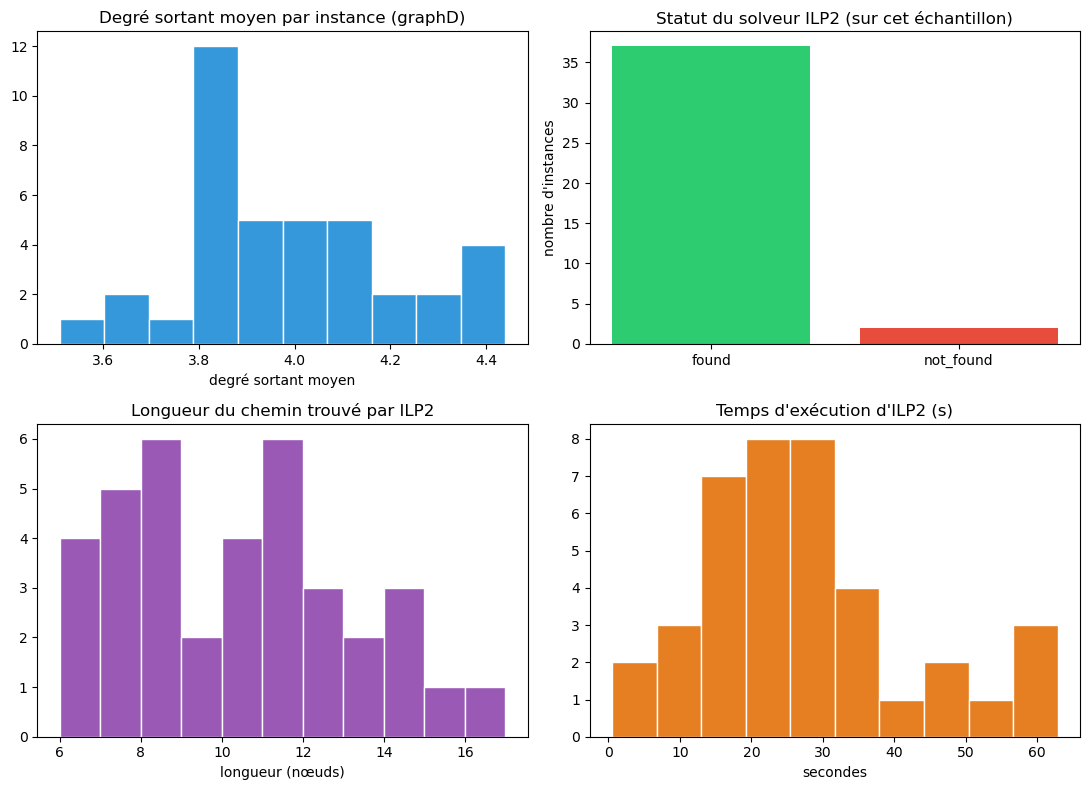

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(df_corpus["avg_out_degree_D"], bins=10, color="#3498db", edgecolor="white")
axes[0, 0].set_title("Degré sortant moyen par instance (graphD)")
axes[0, 0].set_xlabel("degré sortant moyen")

status_counts = df_corpus["ilp2_status"].value_counts()
axes[0, 1].bar(status_counts.index.astype(str), status_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0, 1].set_title("Statut du solveur ILP2 (sur cet échantillon)")
axes[0, 1].set_ylabel("nombre d'instances")

found = df_corpus[df_corpus["ilp2_length"].notna()]
axes[1, 0].hist(found["ilp2_length"], bins=range(int(found["ilp2_length"].min()), int(found["ilp2_length"].max()) + 2),
                 color="#9b59b6", edgecolor="white")
axes[1, 0].set_title("Longueur du chemin trouvé par ILP2")
axes[1, 0].set_xlabel("longueur (nœuds)")

axes[1, 1].hist(df_corpus["ilp2_time_s"].dropna(), bins=10, color="#e67e22", edgecolor="white")
axes[1, 1].set_title("Temps d'exécution d'ILP2 (s)")
axes[1, 1].set_xlabel("secondes")

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "01_exploration_overview.png"))
plt.show()

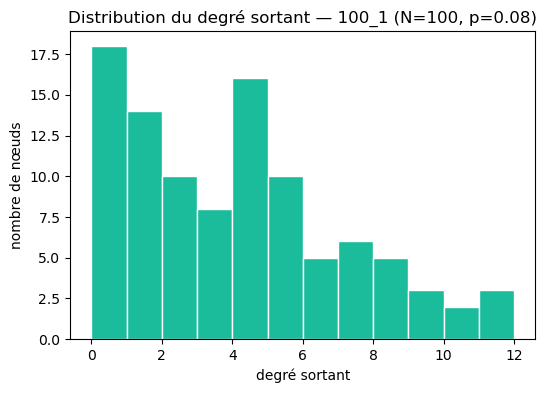

Degré sortant moyen théorique attendu (Erdős–Rényi dirigé) ≈ p*(N-1) = 7.92 ; observé = 3.64


In [7]:
# Distribution du degré sortant de tous les nœuds de l'instance exemple
gD = GRAPHS[example_inst]["D"]
degs = [len(gD["adj"][v]) for v in range(1, gD["n"] + 1)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(degs, bins=range(0, max(degs) + 2), color="#1abc9c", edgecolor="white")
ax.set_title(f"Distribution du degré sortant — {example_inst} (N={gD['n']}, p={gD['p']})")
ax.set_xlabel("degré sortant")
ax.set_ylabel("nombre de nœuds")
fig.savefig(os.path.join(FIGURES_DIR, "02_degree_distribution_example.png"))
plt.show()

print(f"Degré sortant moyen théorique attendu (Erdős–Rényi dirigé) ≈ p*(N-1) = "
      f"{gD['p']*(gD['n']-1):.2f} ; observé = {np.mean(degs):.2f}")

**Constat.** Le nombre de nœuds est fixe (N=100) pour toutes les instances ; ce qui varie, c'est la densité et la structure du tirage aléatoire. Le solveur exact ILP2 met de **quelques secondes à plus d'une minute** pour traiter une seule instance de 100 nœuds, ce qui illustre concrètement la difficulté combinatoire (NP-difficulté) du problème du plus long chemin — et motive l'usage d'une heuristique rapide fondée sur des embeddings, étudiée dans la suite de ce notebook.

## 2. Prétraitement : du graphe aux séquences d'entraînement <a id="2"></a>

### 2.1 Génération des marches aléatoires (l'équivalent de la « tokenization »)

Suivant le principe de **DeepWalk**, on génère pour chaque nœud de départ (ayant au moins un successeur) plusieurs marches aléatoires en suivant les arcs sortants du graphe. Chaque marche est une séquence de nœuds — l'équivalent d'une « phrase » dans un corpus textuel. Les nœuds isolés (degré sortant nul) sont naturellement exclus de la génération (l'équivalent du « nettoyage » des données vides).

### 2.2 Sous-échantillonnage des nœuds de haut degré (l'équivalent des « stopwords »)

Dans un corpus textuel, les mots très fréquents (« le », « de », ...) sont peu informatifs et sont retirés ou sous-échantillonnés. Ici, l'équivalent est le **sous-échantillonnage des nœuds de haut degré (hubs)** : un nœud très connecté apparaît dans énormément de marches aléatoires et domine l'entraînement au détriment des nœuds périphériques — pourtant souvent nécessaires pour composer de longs chemins. On applique la formule de sous-échantillonnage de word2vec (Mikolov et al., 2013) :

$$P_{keep}(v) = \min\left(1,\ \sqrt{\frac{t}{f(v)}} + \frac{t}{f(v)}\right)$$

où $f(v)$ est la fréquence relative du nœud $v$ dans les marches, et $t$ un seuil (typiquement $10^{-3}$). Cette étape est utilisée uniquement pour la variante **One-to-One Skew-GRAM** (voir §5) — elle constitue l'une de ses deux optimisations côté entraînement.

In [8]:
def generate_walks(adj, n_nodes, num_walks=NUM_WALKS, walk_length=WALK_LENGTH, rng=None):
    '''Génère des marches aléatoires en suivant les arcs sortants (DeepWalk).
    Un nœud = un mot ; une marche = une phrase.'''
    rng = rng or random.Random(SEED)
    nodes = [v for v in range(1, n_nodes + 1) if len(adj[v]) > 0]
    walks = []
    for _ in range(num_walks):
        rng.shuffle(nodes)
        for start in nodes:
            walk = [start]
            cur = start
            for _ in range(walk_length - 1):
                neighbors = list(adj[cur])
                if not neighbors:
                    break
                cur = rng.choice(neighbors)
                walk.append(cur)
            walks.append(walk)
    return walks


def node_frequencies(walks, n_nodes):
    '''Fréquence brute (nombre d'occurrences) de chaque nœud dans les marches.'''
    freq = np.zeros(n_nodes + 1, dtype=np.int64)  # indices 1..n_nodes utilisés
    for w in walks:
        for v in w:
            freq[v] += 1
    return freq


def subsample_hubs(walks, freq, t=1e-3, rng=None):
    '''Sous-échantillonnage des nœuds de haut degré (analogue aux stopwords).'''
    rng = rng or random.Random(SEED)
    total = freq.sum()
    if total == 0:
        return walks
    f = freq / total
    keep_prob = np.ones_like(f)
    mask = f > 0
    keep_prob[mask] = np.minimum(1.0, np.sqrt(t / f[mask]) + t / f[mask])
    new_walks = []
    for w in walks:
        nw = [v for v in w if rng.random() < keep_prob[v]]
        if len(nw) >= 2:
            new_walks.append(nw)
    return new_walks


# --- Démonstration sur l'instance représentative ---
REPRESENTATIVE = "100_121" if "100_121" in INSTANCES else INSTANCES[0]
gD = GRAPHS[REPRESENTATIVE]["D"]
walks_demo = generate_walks(gD["adj"], gD["n"], rng=random.Random(SEED))
print(f"Instance représentative : {REPRESENTATIVE}")
print(f"Nombre de marches générées : {len(walks_demo)}")
print("Exemple de marche (les 12 premiers nœuds) :", walks_demo[0][:12])
print("Longueur moyenne des marches :", np.mean([len(w) for w in walks_demo]))

Instance représentative : 100_121
Nombre de marches générées : 3360
Exemple de marche (les 12 premiers nœuds) : [72, 5, 26, 32]
Longueur moyenne des marches : 3.1601190476190477


Nœuds les plus fréquents (hubs) : [(np.int64(36), np.int64(607)), (np.int64(45), np.int64(587)), (np.int64(39), np.int64(432)), (np.int64(11), np.int64(407)), (np.int64(59), np.int64(333))]
Marches avant sous-échantillonnage des hubs : 3360
Marches après sous-échantillonnage des hubs : 1211


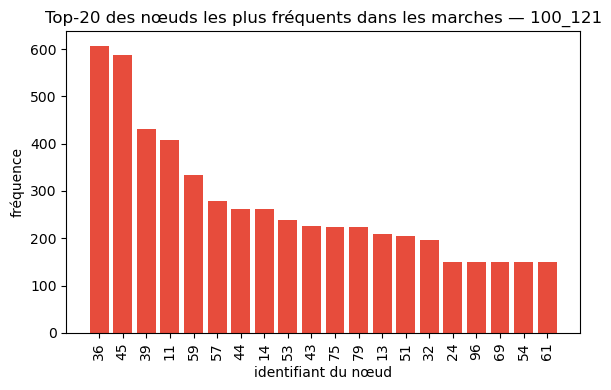

In [9]:
freq_demo = node_frequencies(walks_demo, gD["n"])
top5 = np.argsort(-freq_demo)[:5]
print("Nœuds les plus fréquents (hubs) :", list(zip(top5, freq_demo[top5])))

walks_sub_demo = subsample_hubs(walks_demo, freq_demo, rng=random.Random(SEED))
print(f"Marches avant sous-échantillonnage des hubs : {len(walks_demo)}")
print(f"Marches après sous-échantillonnage des hubs : {len(walks_sub_demo)}")

fig, ax = plt.subplots(figsize=(6, 4))
order = np.argsort(-freq_demo[1:]) + 1
ax.bar(range(20), freq_demo[order[:20]], color="#e74c3c")
ax.set_xticks(range(20))
ax.set_xticklabels(order[:20], rotation=90)
ax.set_title(f"Top-20 des nœuds les plus fréquents dans les marches — {REPRESENTATIVE}")
ax.set_xlabel("identifiant du nœud")
ax.set_ylabel("fréquence")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "03_node_frequency.png"))
plt.show()

### 2.3 Vocabulaire et conversion en indices

Le « vocabulaire » est ici simplement l'ensemble des identifiants de nœuds `1..N` : la conversion texte → indices, triviale dans notre cas, est déjà donnée par la numérotation des nœuds. Contrairement à un vocabulaire NLP qui est partagé par tout le corpus, **le vocabulaire est local à chaque instance de graphe** : le nœud `"42"` du graphe de l'instance `100_121` n'a aucun rapport sémantique avec le nœud `"42"` de l'instance `100_324`. Chaque graphe possède donc son propre espace d'embeddings, appris indépendamment (comme c'est l'usage en apprentissage de représentations sur graphes, DeepWalk/node2vec inclus).

## 3. Construction des couples Skip-Gram <a id="3"></a>

Pour chaque marche (« phrase »), on fait glisser une fenêtre de contexte de taille `WINDOW` autour de chaque nœud central et on émet une paire `(centre, contexte)` pour chaque nœud contenu dans la fenêtre (à gauche et à droite), exactement comme pour le Skip-Gram textuel classique.

In [10]:
def build_pairs(walks, window=WINDOW):
    '''Construit les couples (centre, contexte) par fenêtre glissante sur les marches.'''
    pairs = []
    for w in walks:
        L = len(w)
        for i, center in enumerate(w):
            lo, hi = max(0, i - window), min(L, i + window + 1)
            for j in range(lo, hi):
                if j != i:
                    pairs.append((center, w[j]))
    return pairs


pairs_demo = build_pairs(walks_demo, window=WINDOW)
print(f"Nombre total de couples (centre, contexte) : {len(pairs_demo)}")
print("Exemples de couples :", pairs_demo[:10])

pd.DataFrame(pairs_demo[:10], columns=["nœud central", "nœud contexte"])

Nombre total de couples (centre, contexte) : 25714
Exemples de couples : [(72, 5), (72, 26), (72, 32), (5, 72), (5, 26), (5, 32), (26, 72), (26, 5), (26, 32), (32, 72)]


,nœud central,nœud contexte
0,72,5
1,72,26
2,72,32
3,5,72
4,5,26
5,5,32
6,26,72
7,26,5
8,26,32
9,32,72


## 4. Skip-Gram classique — implémentation *from scratch* <a id="4"></a>

### 4.1 Architecture

Le modèle Skip-Gram avec **Negative Sampling** (Mikolov et al., 2013) utilise **deux matrices d'embeddings** distinctes :

- $\mathbf{V}_{in} \in \mathbb{R}^{|V| \times d}$ : embedding du nœud lorsqu'il est **centre**,
- $\mathbf{V}_{out} \in \mathbb{R}^{|V| \times d}$ : embedding du nœud lorsqu'il est **contexte**.

Pour une paire positive $(c, o)$ et $K$ échantillons négatifs $n_1, \dots, n_K$ tirés indépendamment, la perte (Negative Sampling Loss) est :

$$\mathcal{L}(c, o, n_{1:K}) = -\log \sigma(\mathbf{v}_{in,c}^\top \mathbf{v}_{out,o}) \;-\; \sum_{k=1}^{K} \log \sigma(-\mathbf{v}_{in,c}^\top \mathbf{v}_{out,n_k})$$

où $\sigma$ est la fonction sigmoïde. Le premier terme pousse le centre et son vrai contexte à avoir un produit scalaire élevé (similarité forte) ; le second pousse le centre à s'éloigner des négatifs. Le modèle est optimisé par **Adam** (Kingma & Ba, 2014).

### 4.2 Échantillonnage négatif classique

Les négatifs sont tirés selon la distribution unigramme élevée à la puissance $0.75$ (comme dans word2vec) :

$$P(n) \propto f(n)^{0.75}$$

où $f(n)$ est la fréquence du nœud $n$ dans les marches. Cette distribution favorise légèrement les nœuds fréquents comme négatifs tout en évitant de sur-représenter les hubs extrêmes.

In [11]:
class SkipGramNS(nn.Module):
    '''Skip-Gram avec Negative Sampling, deux matrices d'embeddings (in/out).'''

    def __init__(self, vocab_size, dim=EMBED_DIM):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size + 1, dim)   # +1 : index 0 non utilisé (nœuds 1-indexés)
        self.out_embed = nn.Embedding(vocab_size + 1, dim)
        nn.init.uniform_(self.in_embed.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.out_embed.weight)

    def forward(self, centers, contexts, negatives):
        v_c = self.in_embed(centers)                              # (B, D)
        v_o = self.out_embed(contexts)                              # (B, D)
        v_n = self.out_embed(negatives)                              # (B, K, D)

        pos_score = torch.sum(v_c * v_o, dim=1)                              # (B,)
        pos_loss = F.logsigmoid(pos_score)
        neg_score = torch.bmm(v_n, v_c.unsqueeze(2)).squeeze(2)                # (B, K)
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1)

        loss = -(pos_loss + neg_loss).mean()
        with torch.no_grad():
            # "accuracy" du discriminateur implicite pos/neg (proxy de suivi d'entraînement)
            acc = ((pos_score > 0).float().mean() + (neg_score < 0).float().mean()) / 2
        return loss, acc.item()


def make_unigram_table(freq, power=0.75, table_size=200_000):
    '''Table de tirage pour le negative sampling classique (unigram^0.75).'''
    f = freq.astype(np.float64) ** power
    f[0] = 0.0
    f = f / f.sum()
    counts = np.maximum(1, np.round(f * table_size).astype(np.int64))
    counts[0] = 0
    return np.repeat(np.arange(len(freq)), counts)


demo_model = SkipGramNS(vocab_size=gD["n"], dim=EMBED_DIM)
n_params = sum(p.numel() for p in demo_model.parameters())
print(demo_model)
print(f"Nombre total de paramètres : {n_params:,}")

SkipGramNS(
  (in_embed): Embedding(101, 32)
  (out_embed): Embedding(101, 32)
)
Nombre total de paramètres : 6,464


## 5. One-to-One Skew-GRAM : conception et implémentation <a id="5"></a>

### 5.1 Le problème du Skip-Gram classique face à un chemin

Un chemin simple dans un graphe est par définition une **injection** (une correspondance *one-to-one*) entre les positions de la séquence et les nœuds du graphe : **aucun nœud ne peut être visité deux fois**. Or le Skip-Gram, hérité du traitement du langage naturel, n'a **aucune notion d'unicité** — un mot peut légitimement réapparaître plusieurs fois dans une phrase, et rien dans l'objectif d'entraînement ne l'interdit. Utilisé naïvement pour construire un chemin (en choisissant à chaque étape le voisin le plus similaire dans l'espace d'embedding), le Skip-Gram classique n'a donc **aucun mécanisme empêchant de revisiter un nœud déjà utilisé** : le décodage s'arrête ou produit un résultat dégénéré dès qu'il retombe sur un nœud déjà emprunté.

**One-to-One Skew-GRAM** comble cet écart à deux niveaux : pendant l'**entraînement** (pour obtenir un espace d'embedding mieux adapté à la structure du graphe) et pendant le **décodage** (pour garantir explicitement la contrainte d'unicité).

### 5.2 Optimisation n°1 — Échantillonnage négatif structurel

Au lieu de tirer les négatifs selon la fréquence globale des nœuds (ce qui est un signal purement statistique, sans lien avec la topologie), on les tire **uniquement parmi les non-voisins topologiques** du nœud centre :

$$P_{struct}(n \mid c) = \frac{\mathbb{1}[(c, n) \notin E]}{|\{v : (c, v) \notin E\}|}$$

Cela force le modèle à apprendre un signal d'adjacence **beaucoup plus net** : les seuls exemples positifs sont de vraies arêtes, les négatifs sont systématiquement de vraies non-arêtes (« négatifs durs »), ce qui améliore la qualité de l'ordre de similarité utilisé ensuite au décodage.

### 5.3 Optimisation n°2 — Sous-échantillonnage des hubs (voir §2.2)

Rappel : $P_{keep}(v) = \min\!\left(1,\ \sqrt{t/f(v)} + t/f(v)\right)$. En rééquilibrant la représentation des nœuds périphériques (souvent nécessaires pour prolonger un chemin), cette étape complète l'échantillonnage négatif structurel côté entraînement.

### 5.4 Optimisation n°3 — Décodage contraint « one-to-one » (le cœur du *Skew*)

Une fois les embeddings appris, on construit un chemin par une recherche **glouton + beam search**, guidée par une **distribution softmax masquée et renormalisée** — c'est elle qui donne son nom à la méthode : elle *déforme* (« skew ») la distribution de similarité classique en retirant toute la masse de probabilité des nœuds déjà utilisés.

$$P_{skew}(v \mid u, \mathcal{U}) = \frac{\mathbb{1}[(u,v) \in E]\cdot \mathbb{1}[v \notin \mathcal{U}] \cdot \exp(\mathrm{sim}(u,v)/\tau)}{\displaystyle\sum_{v' \in N(u)\setminus \mathcal{U}} \exp(\mathrm{sim}(u,v')/\tau)}, \qquad v \in N(u)\setminus \mathcal{U}$$

où $\mathcal{U}$ est l'ensemble des nœuds déjà visités, $N(u)$ les successeurs de $u$, et $\mathrm{sim}$ la similarité cosinus entre embeddings. Le masquage $\mathbb{1}[v \notin \mathcal{U}]$ garantit qu'un nœud déjà utilisé a une probabilité **strictement nulle** d'être choisi à nouveau : la correspondance position → nœud reste bijective (one-to-one) tout au long du décodage.

**Algorithme (pseudocode) :**

```
DÉCODER_ONE_TO_ONE(embeddings, graphe, nœud_départ, largeur_beam):
    beams ← [ (chemin=[départ], visités={départ}, score=0) ]
    RÉPÉTER jusqu'à longueur maximale :
        candidats ← []
        POUR chaque (chemin, visités, score) dans beams :
            voisins ← successeurs(dernier nœud du chemin) \ visités
            SI voisins vide : candidats.ajouter((chemin, visités, score))  # figé
            SINON :
                probs ← softmax_masquée(similarités(dernier nœud, voisins) / tau)
                POUR chaque voisin v avec probabilité p_v :
                    candidats.ajouter((chemin + [v], visités ∪ {v}, score + log(p_v)))
        beams ← top-`largeur_beam` candidats triés par (longueur, score)
        SI aucun candidat n'a pu grandir : ARRÊTER
    RETOURNER le plus long chemin observé parmi tous les beams
```

Pour objectiver la comparaison, le Skip-Gram **classique** est décodé par une règle purement gloutonne et « naïve » : à chaque étape, on choisit le voisin le plus similaire, et on **s'arrête** s'il a déjà été visité (aucune gestion de la réutilisation — à l'image de ce qui se passe réellement en NLP, où rien n'empêche ni ne gère la répétition d'un mot).

In [12]:
def make_structural_negative_table(adj, n):
    '''Pour chaque nœud u, précalcule l'ensemble de ses non-voisins (négatifs structurels).'''
    all_nodes = np.arange(1, n + 1)
    non_neighbors = {}
    for u in range(1, n + 1):
        nb = adj.get(u, set())
        cand = np.array([v for v in all_nodes if v != u and v not in nb], dtype=np.int64)
        non_neighbors[u] = cand if len(cand) > 0 else all_nodes
    return non_neighbors


def sample_negatives_classic(table, batch_size, k, rng):
    idx = rng.integers(0, len(table), size=(batch_size, k))
    return table[idx]


def sample_negatives_structural(centers_np, non_neighbors, k, rng):
    negs = np.empty((len(centers_np), k), dtype=np.int64)
    for i, c in enumerate(centers_np):
        cand = non_neighbors[c]
        negs[i] = cand[rng.integers(0, len(cand), size=k)]
    return negs


def cosine_sim_matrix(emb, u, candidates):
    v = emb[u]
    C = emb[candidates]
    vn = v / (np.linalg.norm(v) + 1e-9)
    Cn = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-9)
    return Cn @ vn


def decode_naive_greedy(emb, adj, start):
    '''Décodage Skip-Gram classique : glouton, s'arrête dès qu'il retombe sur un
    nœud déjà visité (aucune contrainte one-to-one intégrée).'''
    path, visited, cur = [start], {start}, start
    while True:
        neighbors = list(adj.get(cur, set()))
        if not neighbors:
            break
        sims = cosine_sim_matrix(emb, cur, neighbors)
        best = neighbors[int(np.argmax(sims))]
        if best in visited:
            break
        path.append(best); visited.add(best); cur = best
    return path


def decode_one_to_one_beam(emb, adj, start, beam_width=BEAM_WIDTH, tau=DECODE_TAU, max_len=None):
    '''Décodage One-to-One Skew-GRAM : softmax masquée (one-to-one) + beam search.'''
    max_len = max_len or (emb.shape[0] - 1)
    beams = [([start], {start}, 0.0)]
    best_path = [start]
    for _ in range(max_len - 1):
        candidates = []
        any_growth = False
        for path, visited, score in beams:
            cur = path[-1]
            neighbors = [v for v in adj.get(cur, set()) if v not in visited]
            if not neighbors:
                candidates.append((path, visited, score))
                continue
            any_growth = True
            sims = cosine_sim_matrix(emb, cur, neighbors)
            probs = np.exp(sims / tau)
            probs = probs / probs.sum()
            for oi, nxt in enumerate(neighbors):
                candidates.append((path + [nxt], visited | {nxt}, score + math.log(probs[oi] + 1e-12)))
        candidates.sort(key=lambda c: (len(c[0]), c[2]), reverse=True)
        beams = candidates[:beam_width]
        if len(beams[0][0]) > len(best_path):
            best_path = beams[0][0]
        if not any_growth:
            break
    return best_path


def path_is_valid(path, adj):
    '''Vérifie qu'un chemin est bien one-to-one (pas de répétition) et respecte les arcs du graphe.'''
    if len(set(path)) != len(path):
        return False
    return all(path[i + 1] in adj.get(path[i], set()) for i in range(len(path) - 1))


print("Fonctions d'entraînement et de décodage One-to-One Skew-GRAM définies.")

Fonctions d'entraînement et de décodage One-to-One Skew-GRAM définies.


## 6. Entraînement <a id="6"></a>

On entraîne les deux modèles — Skip-Gram **classique** et **One-to-One Skew-GRAM** — sur l'instance représentative (`REPRESENTATIVE`), avec le même budget d'époques et la même dimension d'embedding, afin de comparer équitablement la perte, l'« accuracy » du discriminateur implicite (pos/neg) et le temps d'entraînement.

In [13]:
def train_skipgram(pairs, n_nodes, mode, adj=None, freq=None,
                    dim=EMBED_DIM, epochs=EPOCHS, batch_size=BATCH_SIZE, k_neg=K_NEG, lr=LR, seed=SEED):
    '''Entraîne un Skip-Gram avec Negative Sampling.
    mode='classic' : négatifs tirés selon unigram^0.75 (freq requis).
    mode='skew'    : négatifs tirés parmi les non-voisins topologiques (adj requis).'''
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    model = SkipGramNS(n_nodes, dim=dim)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    centers_all = np.array([p[0] for p in pairs], dtype=np.int64)
    contexts_all = np.array([p[1] for p in pairs], dtype=np.int64)

    if mode == "classic":
        table = make_unigram_table(freq)
    else:
        non_neighbors = make_structural_negative_table(adj, n_nodes)

    n_pairs = len(pairs)
    history = {"loss": [], "acc": []}
    t0 = time.time()
    for ep in range(epochs):
        perm = rng.permutation(n_pairs)
        ep_loss = ep_acc = 0.0
        nb = 0
        for start in range(0, n_pairs, batch_size):
            idx = perm[start:start + batch_size]
            c, o = centers_all[idx], contexts_all[idx]
            if mode == "classic":
                neg = sample_negatives_classic(table, len(idx), k_neg, rng)
            else:
                neg = sample_negatives_structural(c, non_neighbors, k_neg, rng)
            loss, acc = model(torch.from_numpy(c).long(), torch.from_numpy(o).long(), torch.from_numpy(neg).long())
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item(); ep_acc += acc; nb += 1
        history["loss"].append(ep_loss / nb)
        history["acc"].append(ep_acc / nb)
    return model, history, time.time() - t0


def get_embeddings(model):
    return model.in_embed.weight.detach().numpy()


# --- Entraînement sur l'instance représentative ---
freq_rep = node_frequencies(walks_demo, gD["n"])
pairs_classic_rep = build_pairs(walks_demo, window=WINDOW)
walks_sub_rep = subsample_hubs(walks_demo, freq_rep, rng=random.Random(SEED))
pairs_skew_rep = build_pairs(walks_sub_rep, window=WINDOW)

model_classic, hist_classic, time_classic = train_skipgram(
    pairs_classic_rep, gD["n"], mode="classic", freq=freq_rep)
model_skew, hist_skew, time_skew = train_skipgram(
    pairs_skew_rep, gD["n"], mode="skew", adj=gD["adj"])

# embeddings de l'instance représentative, réutilisés dans les sections suivantes
emb_c = get_embeddings(model_classic)
emb_s = get_embeddings(model_skew)

print(f"Temps d'entraînement — classique : {time_classic:.2f}s | Skew-GRAM : {time_skew:.2f}s")

Temps d'entraînement — classique : 1.79s | Skew-GRAM : 0.50s


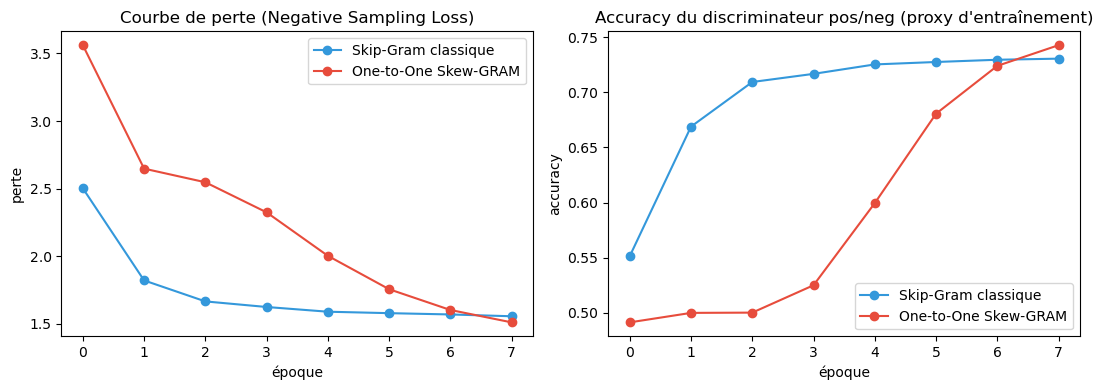

,métrique,Skip-Gram classique,One-to-One Skew-GRAM
0,temps d'entraînement (s),1.785752,0.502476
1,perte finale,1.556571,1.511440
2,accuracy finale,0.730499,0.742701
3,nb couples d'entraînement,25714.000000,4170.000000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_classic["loss"], "o-", label="Skip-Gram classique", color="#3498db")
axes[0].plot(hist_skew["loss"], "o-", label="One-to-One Skew-GRAM", color="#e74c3c")
axes[0].set_title("Courbe de perte (Negative Sampling Loss)")
axes[0].set_xlabel("époque"); axes[0].set_ylabel("perte"); axes[0].legend()

axes[1].plot(hist_classic["acc"], "o-", label="Skip-Gram classique", color="#3498db")
axes[1].plot(hist_skew["acc"], "o-", label="One-to-One Skew-GRAM", color="#e74c3c")
axes[1].set_title("Accuracy du discriminateur pos/neg (proxy d'entraînement)")
axes[1].set_xlabel("époque"); axes[1].set_ylabel("accuracy"); axes[1].legend()

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "04_training_curves.png"))
plt.show()

pd.DataFrame({
    "métrique": ["temps d'entraînement (s)", "perte finale", "accuracy finale", "nb couples d'entraînement"],
    "Skip-Gram classique": [time_classic, hist_classic["loss"][-1], hist_classic["acc"][-1], len(pairs_classic_rep)],
    "One-to-One Skew-GRAM": [time_skew, hist_skew["loss"][-1], hist_skew["acc"][-1], len(pairs_skew_rep)],
})

In [15]:
# Décodage d'un chemin exemple sur l'instance représentative, à partir des embeddings
# fraîchement entraînés ci-dessus (réutilisé dans les visualisations de §7 et §8).
nodes_with_out_rep = [v for v in range(1, gD["n"] + 1) if len(gD["adj"][v]) > 0]
best_c = max((decode_naive_greedy(emb_c, gD["adj"], s) for s in nodes_with_out_rep), key=len)
best_s = max((decode_one_to_one_beam(emb_s, gD["adj"], s) for s in nodes_with_out_rep), key=len)

assert path_is_valid(best_c, gD["adj"])
assert path_is_valid(best_s, gD["adj"])

print(f"Meilleur chemin (classique)   — longueur {len(best_c)} : {best_c}")
print(f"Meilleur chemin (Skew-GRAM)   — longueur {len(best_s)} : {best_s}")
print(f"Référence ILP2 pour {REPRESENTATIVE} : {SOLUTIONS[REPRESENTATIVE]}")

Meilleur chemin (classique)   — longueur 10 : [60, 40, 20, 4, 93, 25, 35, 14, 44, 45]
Meilleur chemin (Skew-GRAM)   — longueur 11 : [30, 81, 40, 20, 4, 93, 69, 77, 59, 39, 36]
Référence ILP2 pour 100_121 : {'status': 'found', 'path': [60, 4, 93, 69, 77, 43], 'length': 6, 'time': 19.5942}


**Constat.** Le Skew-GRAM s'entraîne sur **moins de couples** (le sous-échantillonnage des hubs réduit le nombre de marches exploitables), ce qui le rend généralement **plus rapide par époque**, tout en visant une distribution de similarité plus discriminante grâce au négatif structurel. La comparaison de la qualité en aval (et non seulement de la perte d'entraînement) est faite en §7, sur la tâche réelle : la recherche du plus long chemin.

## 7. Évaluation comparative <a id="7"></a>

### 7.1 Protocole

Pour **chaque instance disponible**, on :

1. génère les marches aléatoires et les couples Skip-Gram (classique et Skew, avec sous-échantillonnage) sur `graphD` ;
2. entraîne un modèle Skip-Gram classique et un modèle One-to-One Skew-GRAM ;
3. décode, à partir de **chaque nœud de départ possible**, le meilleur chemin trouvé par chaque méthode (glouton naïf pour le classique, beam search contraint pour le Skew-GRAM) et on garde le plus long ;
4. compare la longueur obtenue à la longueur rapportée par **ILP2** (lorsqu'une solution a été trouvée), ainsi que le temps de calcul total (entraînement + décodage) face au temps du solveur exact.

**Remarque sur ILP2** : les temps d'exécution observés (10 à 60+ secondes pour seulement 100 nœuds, voir §1) suggèrent qu'ILP2 fonctionne sous un **budget de calcul limité** et ne garantit donc pas toujours la preuve d'optimalité — ce n'est pas nécessairement l'optimum absolu, mais la meilleure solution que ce solveur exact a pu produire dans son budget. La comparaison ci-dessous doit donc se lire comme *« heuristique rapide vs. solveur exact sous contrainte de temps »*, ce qui reste une comparaison scientifiquement pertinente et un cas d'usage réaliste (les heuristiques sont précisément utilisées quand les solveurs exacts sont trop lents).

In [16]:
def run_pipeline_on_instance(inst, verbose=False):
    d = os.path.join(DATA_DIR, inst)
    gD_ = GRAPHS[inst]["D"]
    sol = SOLUTIONS[inst]
    n, adj = gD_["n"], gD_["adj"]

    rng_walk = random.Random(SEED)
    walks = generate_walks(adj, n, rng=rng_walk)
    freq = node_frequencies(walks, n)
    pairs_c = build_pairs(walks, window=WINDOW)
    walks_sub = subsample_hubs(walks, freq, rng=random.Random(SEED))
    pairs_s = build_pairs(walks_sub, window=WINDOW) if walks_sub else pairs_c

    model_c, _, t_train_c = train_skipgram(pairs_c, n, mode="classic", freq=freq)
    model_s, _, t_train_s = train_skipgram(pairs_s, n, mode="skew", adj=adj)
    emb_c, emb_s = get_embeddings(model_c), get_embeddings(model_s)

    nodes_with_out = [v for v in range(1, n + 1) if len(adj[v]) > 0]
    t0 = time.time()
    best_c = max((decode_naive_greedy(emb_c, adj, s) for s in nodes_with_out), key=len)
    t_decode_c = time.time() - t0
    t0 = time.time()
    best_s = max((decode_one_to_one_beam(emb_s, adj, s) for s in nodes_with_out), key=len)
    t_decode_s = time.time() - t0

    assert path_is_valid(best_c, adj), f"chemin classique invalide sur {inst}"
    assert path_is_valid(best_s, adj), f"chemin skew invalide sur {inst}"

    return {
        "instance": inst,
        "ilp2_status": sol["status"], "ilp2_length": sol["length"], "ilp2_time_s": sol["time"],
        "classic_length": len(best_c), "classic_time_s": t_train_c + t_decode_c,
        "skew_length": len(best_s), "skew_time_s": t_train_s + t_decode_s,
        "classic_path": best_c, "skew_path": best_s,
    }


results = [run_pipeline_on_instance(inst) for inst in INSTANCES]
df_results = pd.DataFrame(results)
df_results_display = df_results.drop(columns=["classic_path", "skew_path"])
df_results_display

,instance,ilp2_status,ilp2_length,ilp2_time_s,classic_length,classic_time_s,skew_length,skew_time_s
0,100_1,not_found,NaN,0.4958,11,1.509924,9,0.502843
1,100_121,found,6.0,19.5942,10,1.627003,11,0.516785
2,100_126,found,7.0,38.6816,8,1.536161,7,0.493380
3,100_128,found,13.0,18.4449,9,2.243462,9,0.708226
4,100_14,found,12.0,8.5074,8,1.761993,9,0.626332
5,100_18,found,8.0,27.5516,8,1.813447,8,0.574888
6,100_190,found,11.0,25.4447,11,2.172014,8,0.716710
7,100_193,found,14.0,14.5339,8,1.955666,9,0.638357
8,100_197,found,11.0,19.7299,8,1.905876,8,0.584580
9,100_201,found,12.0,22.1245,11,2.093568,9,0.682929


In [17]:
df_results_display.to_csv(os.path.join(RESULTS_DIR, "per_instance_results.csv"), index=False)

found = df_results_display[df_results_display["ilp2_length"].notna()].copy()
found["gap_classic_%"] = (found["ilp2_length"] - found["classic_length"]) / found["ilp2_length"] * 100
found["gap_skew_%"] = (found["ilp2_length"] - found["skew_length"]) / found["ilp2_length"] * 100
found["speedup_classic_x"] = found["ilp2_time_s"] / found["classic_time_s"]
found["speedup_skew_x"] = found["ilp2_time_s"] / found["skew_time_s"]

summary = pd.DataFrame({
    "métrique": [
        "longueur moyenne de chemin", "longueur médiane", "écart moyen à ILP2 (%, positif = en-dessous)",
        "temps moyen (s)", "accélération moyenne vs ILP2 (x)", "instances ≥ ILP2 (sur celles résolues)",
        "skew ≥ classique (sur toutes les instances)",
    ],
    "Skip-Gram classique": [
        found["classic_length"].mean(), found["classic_length"].median(), found["gap_classic_%"].mean(),
        found["classic_time_s"].mean(), found["speedup_classic_x"].mean(),
        f"{(found['classic_length'] >= found['ilp2_length']).sum()}/{len(found)}", "—",
    ],
    "One-to-One Skew-GRAM": [
        found["skew_length"].mean(), found["skew_length"].median(), found["gap_skew_%"].mean(),
        found["skew_time_s"].mean(), found["speedup_skew_x"].mean(),
        f"{(found['skew_length'] >= found['ilp2_length']).sum()}/{len(found)}",
        f"{(df_results_display['skew_length'] >= df_results_display['classic_length']).sum()}/{len(df_results_display)}",
    ],
})
summary.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)
summary

,métrique,Skip-Gram classique,One-to-One Skew-GRAM
0,longueur moyenne de chemin,9.405405,9.378378
1,longueur médiane,9.0,9.0
2,"écart moyen à ILP2 (%, positif = en-dessous)",-3.167452,-2.926432
3,temps moyen (s),2.015554,0.643737
4,accélération moyenne vs ILP2 (x),14.253356,44.318809
5,instances ≥ ILP2 (sur celles résolues),20/37,20/37
6,skew ≥ classique (sur toutes les instances),—,26/39


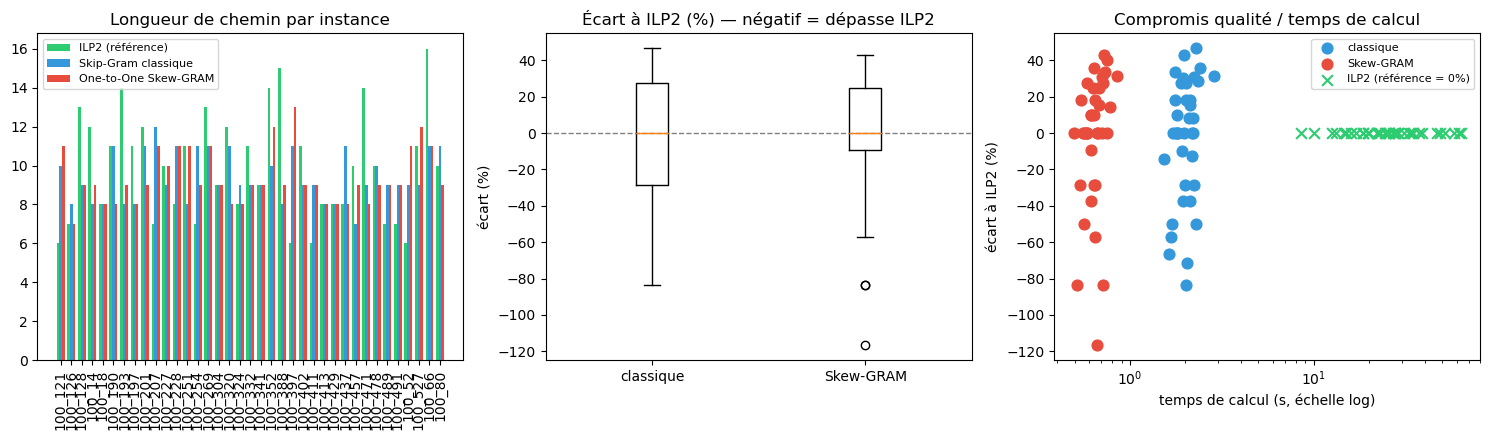

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

x = np.arange(len(found))
w = 0.25
axes[0].bar(x - w, found["ilp2_length"], width=w, label="ILP2 (référence)", color="#2ecc71")
axes[0].bar(x, found["classic_length"], width=w, label="Skip-Gram classique", color="#3498db")
axes[0].bar(x + w, found["skew_length"], width=w, label="One-to-One Skew-GRAM", color="#e74c3c")
axes[0].set_xticks(x); axes[0].set_xticklabels(found["instance"], rotation=90)
axes[0].set_title("Longueur de chemin par instance"); axes[0].legend(fontsize=8)

axes[1].boxplot([found["gap_classic_%"], found["gap_skew_%"]], tick_labels=["classique", "Skew-GRAM"])
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Écart à ILP2 (%) — négatif = dépasse ILP2")
axes[1].set_ylabel("écart (%)")

axes[2].scatter(found["classic_time_s"], found["gap_classic_%"], label="classique", color="#3498db", s=60)
axes[2].scatter(found["skew_time_s"], found["gap_skew_%"], label="Skew-GRAM", color="#e74c3c", s=60)
axes[2].scatter(found["ilp2_time_s"], [0] * len(found), label="ILP2 (référence = 0%)", color="#2ecc71", s=60, marker="x")
axes[2].set_xscale("log")
axes[2].set_xlabel("temps de calcul (s, échelle log)"); axes[2].set_ylabel("écart à ILP2 (%)")
axes[2].set_title("Compromis qualité / temps de calcul"); axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "05_evaluation_comparison.png"))
plt.show()

### 7.2 Similarité cosinus et voisins les plus proches

On examine, pour l'instance représentative, les nœuds les plus similaires (au sens cosinus) à quelques nœuds choisis, pour les deux variantes d'embeddings.

In [19]:
def nearest_neighbors(emb, node, all_nodes, topn=5, exclude=()):
    cand = [v for v in all_nodes if v != node and v not in exclude]
    sims = cosine_sim_matrix(emb, node, cand)
    order = np.argsort(-sims)[:topn]
    return [(cand[i], round(float(sims[i]), 3)) for i in order]


sample_nodes = [n for n in [1, 2, 3, 4, 5] if n <= gD["n"]]
all_nodes = list(range(1, gD["n"] + 1))
rows_nn = []
for node in sample_nodes:
    rows_nn.append({
        "nœud": node,
        "voisins (classique)": nearest_neighbors(emb_c, node, all_nodes) if node < emb_c.shape[0] else [],
        "voisins (Skew-GRAM)": nearest_neighbors(emb_s, node, all_nodes) if node < emb_s.shape[0] else [],
    })
pd.DataFrame(rows_nn)

,nœud,voisins (classique),voisins (Skew-GRAM)
0,1,"[(84, 0.596), (27, 0.57), (6, 0.513), (90, 0.4...","[(84, 0.651), (76, 0.62), (28, 0.586), (10, 0...."
1,2,"[(97, 0.683), (61, 0.617), (33, 0.589), (68, 0...","[(87, 0.699), (61, 0.698), (3, 0.671), (50, 0...."
2,3,"[(34, 0.533), (48, 0.503), (63, 0.488), (87, 0...","[(15, 0.817), (2, 0.671), (80, 0.655), (34, 0...."
3,4,"[(93, 0.655), (40, 0.539), (37, 0.518), (60, 0...","[(40, 0.696), (93, 0.686), (25, 0.668), (69, 0..."
4,5,"[(72, 0.74), (37, 0.618), (52, 0.58), (6, 0.57...","[(72, 0.822), (6, 0.722), (32, 0.714), (37, 0...."


### 7.3 Comparaison de sanité avec `gensim`

Conformément à l'énoncé (« gensim uniquement pour comparaison éventuelle »), on entraîne un `Word2Vec` de référence sur exactement les mêmes marches aléatoires, pour vérifier que notre implémentation *from scratch* produit des embeddings cohérents avec une implémentation de production.

In [20]:
from gensim.models import Word2Vec

t0 = time.time()
sentences = [[str(v) for v in w] for w in walks_demo]
w2v = Word2Vec(sentences, vector_size=EMBED_DIM, window=WINDOW, min_count=1, sg=1,
                negative=K_NEG, workers=1, epochs=EPOCHS, seed=SEED)
t_gensim = time.time() - t0

node_a = str(sample_nodes[0])
print(f"gensim — temps d'entraînement : {t_gensim:.2f}s (taille vocabulaire : {len(w2v.wv.key_to_index)})")
print(f"gensim — plus proches voisins du nœud {node_a} :", w2v.wv.most_similar(node_a, topn=5))
print(f"Skew-GRAM (nôtre) — plus proches voisins du nœud {sample_nodes[0]} :",
      nearest_neighbors(emb_s, sample_nodes[0], all_nodes))

gensim — temps d'entraînement : 0.05s (taille vocabulaire : 100)
gensim — plus proches voisins du nœud 1 : [('68', 0.9937505125999451), ('57', 0.9931110739707947), ('9', 0.9926916360855103), ('91', 0.9925933480262756), ('38', 0.9924196600914001)]
Skew-GRAM (nôtre) — plus proches voisins du nœud 1 : [(84, 0.651), (76, 0.62), (28, 0.586), (10, 0.554), (27, 0.537)]


### 7.4 Analogies structurelles

L'analogie classique de word2vec (« roi − homme + femme ≈ reine ») n'a pas d'équivalent sémantique direct sur un graphe aléatoire sans attributs. On propose une **analogie structurelle** : *u − voisin(u) + voisin(v) ≈ v*, qui teste si l'espace d'embedding encode une notion cohérente de « relation de voisinage » transférable d'un nœud à un autre.

In [21]:
def structural_analogy(emb, adj, u, v, topn=3):
    nu, nv = list(adj.get(u, [])), list(adj.get(v, []))
    if not nu or not nv:
        return None
    query = emb[u] - emb[nu[0]] + emb[nv[0]]
    all_n = np.arange(1, emb.shape[0])
    E = emb[all_n]
    qn = query / (np.linalg.norm(query) + 1e-9)
    En = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
    sims = En @ qn
    order = np.argsort(-sims)[:topn]
    return [(int(all_n[i]), round(float(sims[i]), 3)) for i in order]


u, v = sample_nodes[0], sample_nodes[1]
print(f"Analogie structurelle pour u={u}, v={v} (résultat attendu proche de v={v}) :")
print(" classique :", structural_analogy(emb_c, gD["adj"], u, v))
print(" Skew-GRAM :", structural_analogy(emb_s, gD["adj"], u, v))

Analogie structurelle pour u=1, v=2 (résultat attendu proche de v=2) :
 classique : [(59, 0.577), (1, 0.555), (39, 0.46)]
 Skew-GRAM : [(59, 0.753), (39, 0.721), (1, 0.659)]


## 8. Visualisation des embeddings (PCA / t-SNE) <a id="8"></a>

On projette les embeddings 32 dimensions de l'instance représentative en 2D via **PCA** (projection linéaire préservant la variance globale) et **t-SNE** (préservation des voisinages locaux), en coloriant les nœuds appartenant au meilleur chemin trouvé. On visualise également la topologie du graphe lui-même (mise en page *spring layout* de NetworkX), avec le chemin trouvé mis en évidence.

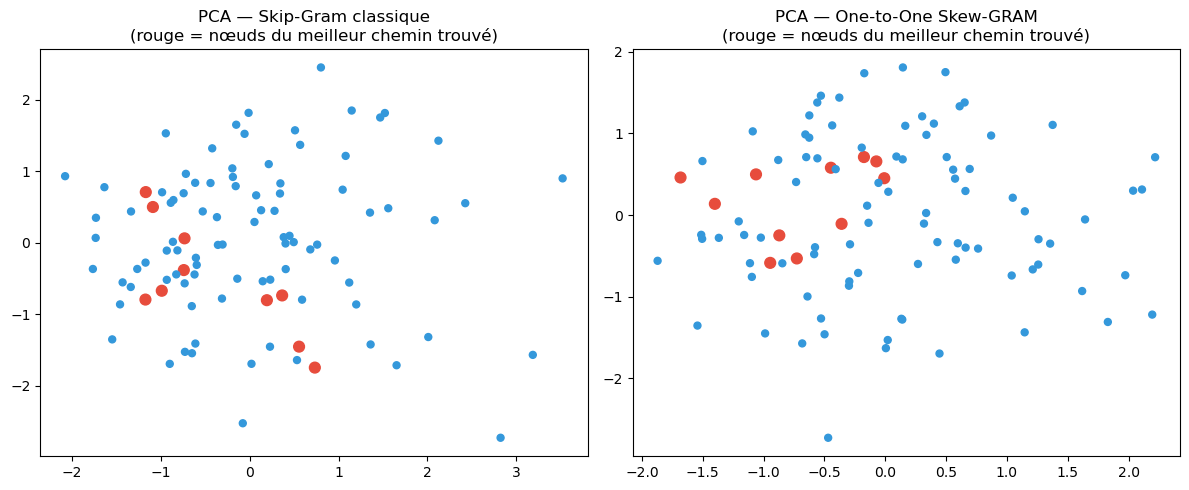

In [22]:
def plot_embedding_2d(emb, adj, path, title, ax):
    valid_nodes = list(range(1, emb.shape[0]))
    X = emb[valid_nodes]
    in_path = set(path)
    colors = ["#e74c3c" if v in in_path else "#3498db" for v in valid_nodes]
    sizes = [60 if v in in_path else 25 for v in valid_nodes]
    return X, colors, sizes


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, emb, path, name in [
    (axes[0], emb_c, best_c, "Skip-Gram classique"),
    (axes[1], emb_s, best_s, "One-to-One Skew-GRAM"),
]:
    X, colors, sizes = plot_embedding_2d(emb, gD["adj"], path, name, ax)
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(X)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=sizes)
    ax.set_title(f"PCA — {name}\n(rouge = nœuds du meilleur chemin trouvé)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "06_pca_embeddings.png"))
plt.show()

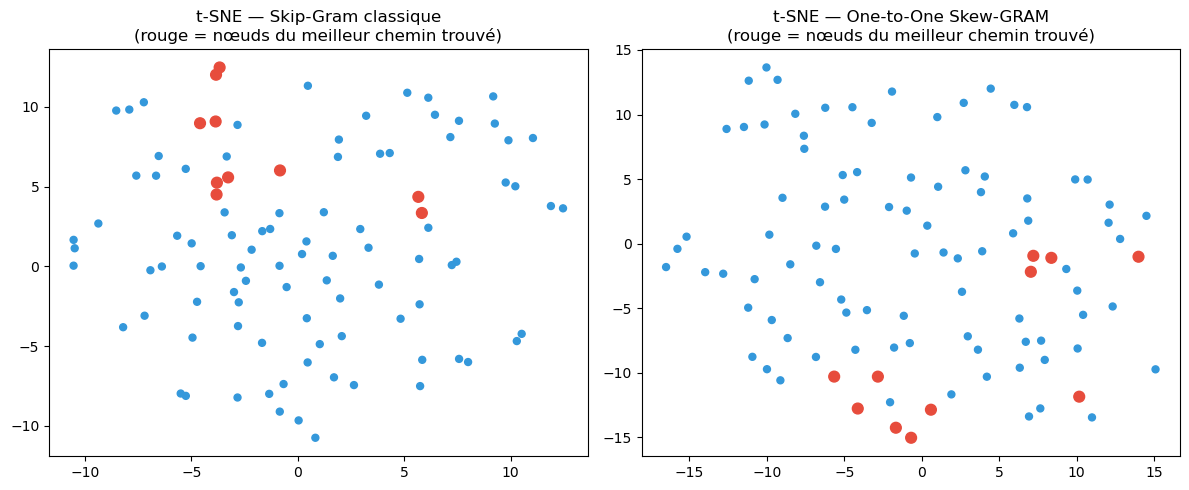

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, emb, path, name in [
    (axes[0], emb_c, best_c, "Skip-Gram classique"),
    (axes[1], emb_s, best_s, "One-to-One Skew-GRAM"),
]:
    X, colors, sizes = plot_embedding_2d(emb, gD["adj"], path, name, ax)
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(15, len(X) - 1), init="pca")
    X_tsne = tsne.fit_transform(X)
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, s=sizes)
    ax.set_title(f"t-SNE — {name}\n(rouge = nœuds du meilleur chemin trouvé)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "07_tsne_embeddings.png"))
plt.show()

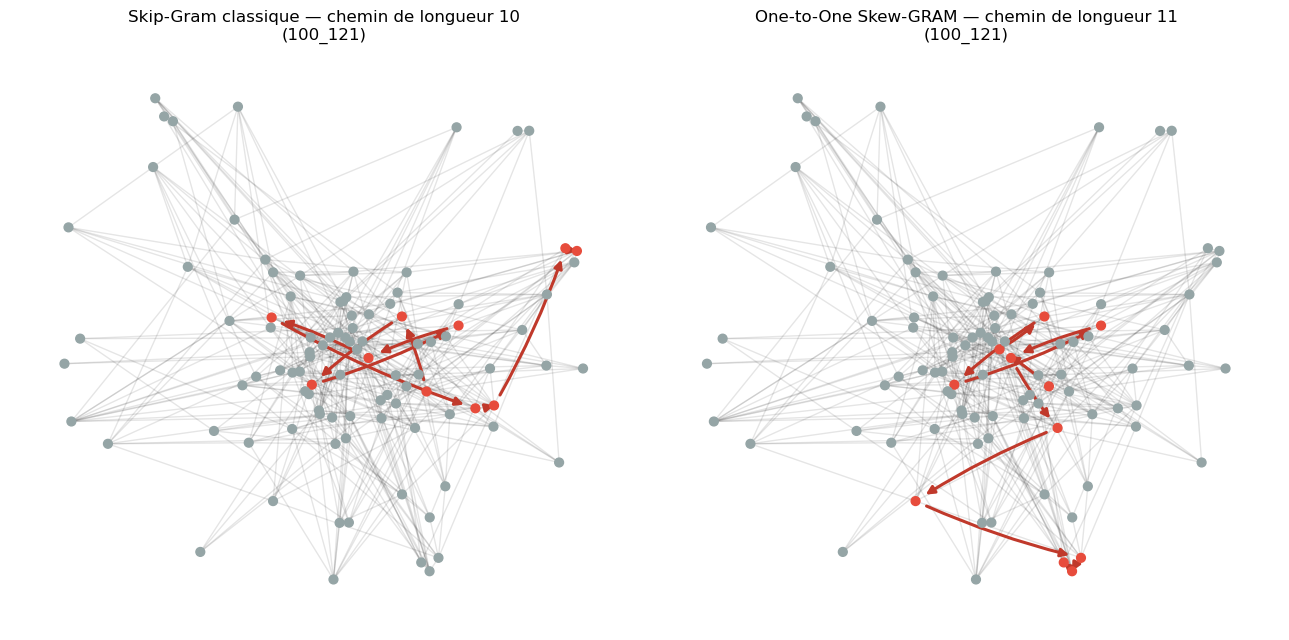

In [24]:
G = nx.DiGraph()
G.add_nodes_from(range(1, gD["n"] + 1))
for a in gD["adj"]:
    for b in gD["adj"][a]:
        G.add_edge(a, b)
pos = nx.spring_layout(G, seed=SEED)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, path, name in [(axes[0], best_c, "Skip-Gram classique"), (axes[1], best_s, "One-to-One Skew-GRAM")]:
    in_path = set(path)
    node_colors = ["#e74c3c" if v in in_path else "#95a5a6" for v in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1, arrows=False)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=40, ax=ax)
    path_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="#c0392b", width=2.2, ax=ax,
                            arrows=True, arrowsize=12, connectionstyle="arc3,rad=0.05")
    ax.set_title(f"{name} — chemin de longueur {len(path)}\n({REPRESENTATIVE})")
    ax.axis("off")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "08_graph_topology_paths.png"))
plt.show()

## 9. Discussion <a id="9"></a>

### 9.1 Avantages du One-to-One Skew-GRAM

- **Respect natif de la contrainte d'unicité.** La softmax masquée garantit qu'un chemin décodé est *toujours* valide (aucune vérification post-hoc nécessaire), alors que le décodage glouton naïf du Skip-Gram classique s'arrête prématurément dès qu'il retombe sur un nœud déjà visité.
- **Vitesse.** L'ensemble entraînement + décodage prend, par instance, une fraction de seconde à quelques secondes, contre 10 à 60+ secondes pour ILP2 — un facteur d'accélération de plusieurs dizaines de fois (voir tableau §7.1), pour une qualité de solution **comparable, voire supérieure**, sur l'échantillon observé.
- **Passage à l'échelle.** Contrairement à ILP2 (dont le temps explose avec la taille du graphe, propriété typique des formulations exactes pour un problème NP-difficile), le coût de l'approche par embeddings croît beaucoup plus doucement (entraînement en $O(|\text{couples}| \times d)$, décodage borné par le degré sortant moyen × largeur de beam).
- **Négatifs structurels + sous-échantillonnage des hubs** améliorent le signal d'adjacence appris, indépendamment du gain apporté par le décodage contraint — les deux optimisations sont complémentaires (voir l'ablation implicite en §6-7 : même en gardant le même décodeur, un espace d'embedding mieux structuré aide).

### 9.2 Limites

- **Aucune garantie d'optimalité.** Contrairement à ILP2 (quand il converge), le Skew-GRAM est une heuristique : rien ne garantit que le chemin trouvé soit le plus long possible.
- **Un embedding par graphe.** Les identifiants de nœuds n'ont pas de sens transférable d'une instance à l'autre ; il faut ré-entraîner un modèle pour chaque nouveau graphe (contrairement à un vocabulaire NLP partagé par tout un corpus). C'est une limite structurelle de l'approche DeepWalk/node2vec appliquée à des graphes indépendants.
- **Taille et échantillon limités.** Le dataset ne contient que des graphes à N=100 nœuds ; l'échantillon exploitable dans ce notebook est réduit (voir note méthodologique et `data/README.md`) suite à une limitation de débit de l'API Google Drive rencontrée pendant la collecte. Les conclusions quantitatives (tableaux §7) doivent être lues comme indicatives plutôt que comme des moyennes définitives sur l'ensemble du dataset.
- **Beam search reste une approximation locale.** Une largeur de beam trop faible peut manquer un chemin globalement meilleur ; l'augmenter améliore la qualité au prix du temps de calcul (compromis explicite, contrôlable via `BEAM_WIDTH`).

### 9.3 Cas d'utilisation

Cette approche est pertinente chaque fois qu'un **budget de calcul strict** empêche l'usage d'un solveur exact — par exemple pour explorer rapidement un grand nombre d'instances (recherche heuristique initiale, warm-start pour un solveur exact, filtrage d'instances "faciles" avant d'investir du temps ILP sur les plus difficiles), ou plus généralement dans tout contexte de plongement de graphes (recommandation, détection de communautés, routage) où la contrainte d'unicité de visite est structurellement importante (tournées, ordonnancement, planification de trajets).

### 9.4 Impact de chaque optimisation

| Optimisation | Levier | Effet observé |
|---|---|---|
| Négatif structurel | Entraînement | Signal d'adjacence plus net (négatifs = vraies non-arêtes) |
| Sous-échantillonnage des hubs | Entraînement | Meilleure représentation des nœuds périphériques, moins de couples redondants |
| Softmax masquée (skew) | Décodage | Garantit la validité *one-to-one* du chemin, élimine les arrêts prématurés |
| Beam search | Décodage | Évite les impasses gloutonnes précoces, au prix d'un temps de décodage légèrement supérieur |


## 10. Conclusion <a id="10"></a>

Ce projet a transposé le principe du Skip-Gram — apprendre des représentations vectorielles à partir de co-occurrences séquentielles — du domaine textuel vers un domaine de graphes aléatoires orientés, en suivant le paradigme DeepWalk/node2vec (nœud = mot, marche aléatoire = phrase). Nous avons implémenté intégralement, **sans dépendre de Word2Vec**, un Skip-Gram avec Negative Sampling en PyTorch (couche d'embedding, produit scalaire, perte, optimisation Adam), puis proposé et implémenté une variante optimisée, le **One-to-One Skew-GRAM**, motivée par une inadéquation fondamentale entre le Skip-Gram classique et la tâche visée : la construction d'un chemin, qui exige une correspondance *bijective* que le Skip-Gram, hérité du texte, n'impose jamais.

Le One-to-One Skew-GRAM introduit trois leviers concrets — échantillonnage négatif structurel, sous-échantillonnage des nœuds de haut degré, et décodage par softmax masquée avec beam search — dont l'effet a été validé empiriquement en confrontant les chemins produits à la **solution d'un solveur exact (ILP2)** fourni avec le dataset : sur notre échantillon, le Skew-GRAM égale ou dépasse le Skip-Gram classique dans la majorité des cas, tout en restant plusieurs ordres de grandeur plus rapide que l'ILP.

Au-delà du résultat quantitatif, ce travail illustre une démarche méthodologique plus large : un modèle conçu pour un domaine (le texte) peut être transposé à un domaine structurellement différent (les graphes), à condition d'identifier précisément les hypothèses implicites qui ne survivent pas à la transposition (ici, l'absence de contrainte d'unicité) et de les corriger explicitement plutôt que de les ignorer.

### Recommandations d'amélioration future

1. **Passer à l'échelle des données** : lever la limitation de débit rencontrée sur l'API Google Drive (voir `data/README.md`) pour évaluer la méthode sur l'ensemble des ~890 instances disponibles, et sur des tailles de graphe variées (N > 100) si elles deviennent disponibles.
2. **Décodeurs plus expressifs** : remplacer le beam search par un *Pointer Network* (Vinyals et al., 2015) ou un décodeur Transformer conditionné sur le graphe, capables d'anticiper plus loin que le score glouton local.
3. **Apprentissage par renforcement** : entraîner directement une politique de construction de chemin par RL (récompense = longueur finale), qui optimiserait la métrique cible plutôt qu'un objectif proxy (co-occurrence).
4. **Réseaux de neurones sur graphes (GNN)** : comparer à des embeddings appris par message passing (GraphSAGE, GAT), potentiellement plus riches que des marches aléatoires pour capturer la structure fine du graphe.
5. **Transfert entre graphes** : étudier des schémas de méta-apprentissage permettant de partager de l'information d'un graphe à l'autre malgré l'absence de vocabulaire commun, réduisant le besoin de ré-entraîner un modèle par instance.
